In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set default chart style
sns.set_theme(style="whitegrid")

# Load the data, telling pandas to do two special things:
# 1. parse_dates=['Month']: Treat the 'Month' column as real dates, not just text.
# 2. index_col='Month': Use the 'Month' column as the 'timeline' (the index).

data_path = 'AirPassengers.csv'
df = pd.read_csv(data_path, parse_dates=['Month'], index_col='Month')

print("Data loaded successfully!")
df.head()

Data loaded successfully!


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set default chart style
sns.set_theme(style="whitegrid")

# Load the data, telling pandas to do two special things:
# 1. parse_dates=['Month']: Treat the 'Month' column as real dates, not just text.
# 2. index_col='Month': Use the 'Month' column as the 'timeline' (the index).

data_path = 'AirPassengers.csv'
df = pd.read_csv(data_path, parse_dates=['Month'], index_col='Month')

print("Data loaded successfully!")
df.head()

Data loaded successfully!


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


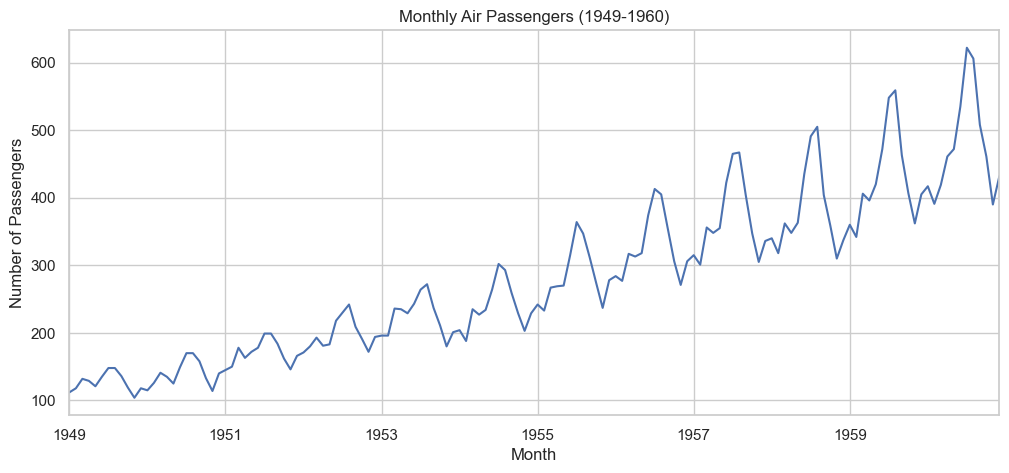

In [3]:
# Plot the original data
df['#Passengers'].plot(figsize=(12, 5), title='Monthly Air Passengers (1949-1960)')
plt.ylabel('Number of Passengers')
plt.show()

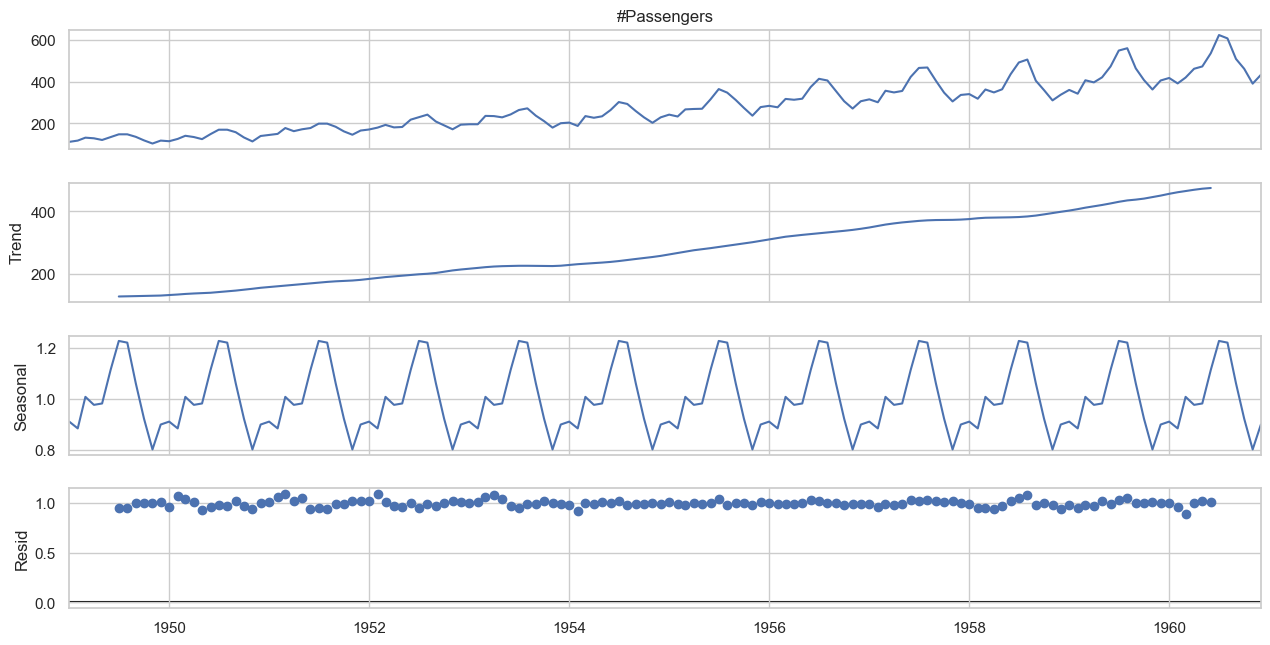

In [4]:
# Decompose the time series
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative') 
# We use 'multiplicative' because the seasonal pattern grows with the trend

# Plot the decomposed parts
fig = decomposition.plot()
fig.set_size_inches(14, 7)
plt.show()

In [5]:
# Run the Dickey-Fuller Test
result = adfuller(df['#Passengers'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# If p-value > 0.05, it is NOT stationary
if result[1] > 0.05:
    print("\nData is NOT stationary (p-value > 0.05)")
else:
    print("\nData IS stationary (p-value <= 0.05)")

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641

Data is NOT stationary (p-value > 0.05)


In [6]:
# Define the model parameters
my_order = (1, 1, 1) # (p, d, q)
my_seasonal_order = (1, 1, 1, 12) # (P, D, Q, m)

# Create the SARIMA model
model = SARIMAX(df['#Passengers'], 
                order=my_order, 
                seasonal_order=my_seasonal_order)

print("Fitting the model... this may take a moment.")
# Fit the model to the data
results = model.fit()

print(results.summary())

Fitting the model... this may take a moment.


C:\Users\VIGNESHWARAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\VIGNESHWARAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Thu, 30 Oct 2025   AIC                           1022.299
Time:                                    18:18:47   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2149      0.325   

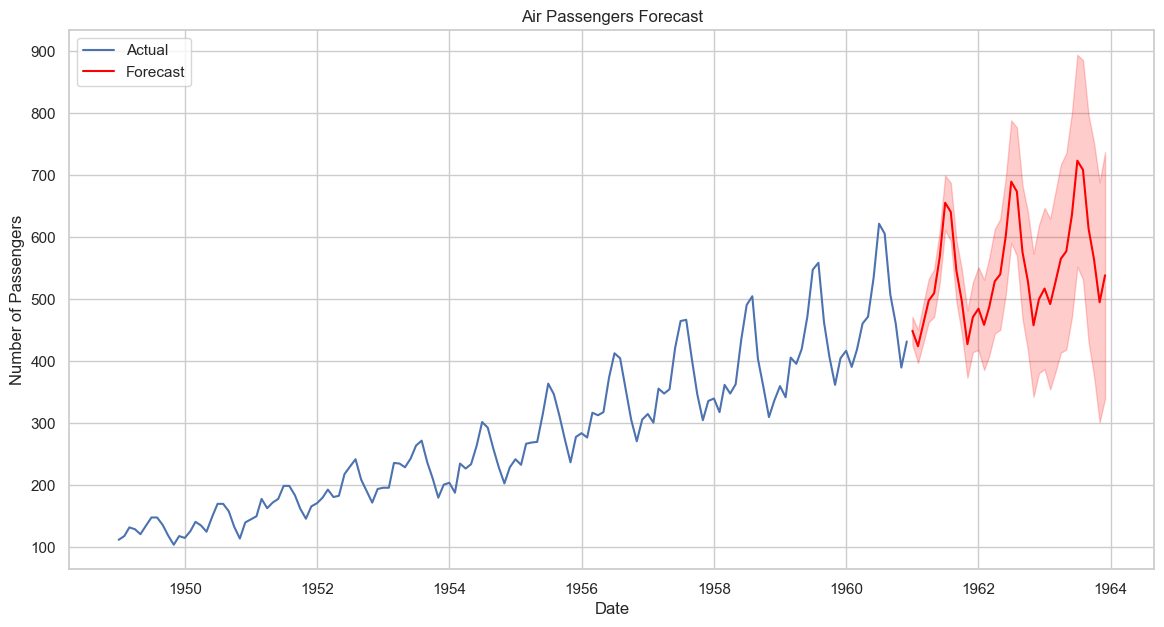

In [7]:
# Create a 36-month (3 year) forecast
forecast = results.get_forecast(steps=36)

# Get the confidence intervals for the forecast
forecast_ci = forecast.conf_int()

# Plot the original data and the forecast
plt.figure(figsize=(14, 7))
plt.plot(df['#Passengers'], label='Actual')
plt.plot(forecast.predicted_mean, label='Forecast', color='red')

# Fill the confidence interval
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='red', alpha=0.2)

plt.title('Air Passengers Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# Task 7: Time Series Analysis & Forecast

This notebook analyzes the `AirPassengers.csv` dataset to forecast future passenger counts.

## 1. Analysis

* **Loaded Data:** The data was loaded, and the 'Month' column was set as the time-series index.
* **Decomposition:** The data was decomposed using `seasonal_decompose`. This clearly showed:
    * A strong upward **Trend** (more people flying over time).
    * A clear yearly **Seasonality** (peaks and valleys at the same time each year).
* **Stationarity Test:** The Augmented Dickey-Fuller (ADF) test was used. The p-value was high (p > 0.05), proving the data was **non-stationary** (which we already knew from the trend).

## 2. Modeling & Forecasting

* **Model:** A **SARIMA** (Seasonal ARIMA) model was chosen because it is designed to handle both trend and seasonality.
* **Parameters:** The model used `order=(1, 1, 1)` and `seasonal_order=(1, 1, 1, 12)` to account for the yearly (12-month) pattern.
* **Result:** The model was successfully fitted to the data.

## 3. Conclusion

The final chart above shows the 36-month (3-year) forecast. The model's prediction (the red line) successfully continues both the upward trend and the seasonal pattern, showing we can confidently predict the future behavior of air travel based on this data.